# Sampling and Estimation in Python
### CFA Level 1 Quantitative Methods | Applied to Real Market Scenarios

---

## The Scenario

You are a quantitative researcher at an asset management firm.

Your portfolio manager comes to you with a question:

> "We have been running our momentum strategy for 6 months.
> The average daily return is 0.08%. But how confident are we
> that this is a real edge and not just luck?
> How much data do we actually need before we can trust this number?"

This is the core problem of **statistical inference**:
using a sample to draw conclusions about a population.

Every backtest, every factor study, every performance evaluation
starts with this problem. Get it wrong and you will
mistake noise for signal — the most common error in quantitative finance.

**What this notebook builds:**
- The Central Limit Theorem — why sample means are normally distributed
- Standard error — how uncertain is our estimate of the mean?
- Confidence intervals — the range where the true mean likely falls
- Required sample size — how much data do we actually need?
- Bootstrap — estimating uncertainty without distributional assumptions

**Data source:** Financial Modeling Prep (FMP) API

## Setup

We will use the following libraries:

- `requests` — to pull data from FMP API
- `pandas` — for data manipulation
- `numpy` — for mathematical operations
- `matplotlib` — for visualizations
- `scipy` — for statistical functions

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import warnings
from dotenv import load_dotenv
import os

load_dotenv()
warnings.filterwarnings('ignore')

FMP_KEY = os.getenv("FMP_KEY")

# Plot styling
plt.rcParams['figure.facecolor'] = '#0D1117'
plt.rcParams['axes.facecolor']   = '#161B22'
plt.rcParams['axes.edgecolor']   = '#30363D'
plt.rcParams['text.color']       = '#E6EDF3'
plt.rcParams['axes.labelcolor']  = '#E6EDF3'
plt.rcParams['xtick.color']      = '#8B949E'
plt.rcParams['ytick.color']      = '#8B949E'
plt.rcParams['grid.color']       = '#21262D'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5

print("Libraries loaded successfully")
print("FMP Key loaded ✓" if FMP_KEY else "FMP Key missing ✗")

Libraries loaded successfully
FMP Key loaded ✓


## 1. Pulling Real Market Data

We pull 5 years of daily returns for a diversified set of assets.
These will serve as our **population** throughout this notebook.

We then repeatedly sample from this population
to demonstrate how sampling works in practice —
and how much our estimates can vary depending on sample size.

**Assets:**
- **SPY** — S&P 500 ETF (equity market)
- **QQQ** — Nasdaq 100 ETF (tech-heavy)
- **IWM** — Russell 2000 ETF (small caps)
- **GLD** — Gold ETF (alternative asset)
- **TLT** — 20+ Year Treasury (bonds)

This cross-section gives us assets with very different
return distributions — which makes the sampling
and estimation results more interesting.

In [2]:
# =============================================================================
# CELL 5 — Pull Market Data from FMP
# =============================================================================

def get_prices(ticker, api_key, from_date="2019-01-01", to_date="2024-01-01"):
    """Pull historical daily closing prices from FMP."""
    url = "https://financialmodelingprep.com/stable/historical-price-eod/full"
    params = {"symbol": ticker, "from": from_date, "to": to_date, "apikey": api_key}
    response = requests.get(url, params=params)
    data = response.json()
    if isinstance(data, list) and len(data) > 0:
        df = pd.DataFrame(data)
    elif isinstance(data, dict) and "historical" in data:
        df = pd.DataFrame(data["historical"])
    else:
        print(f"  ✗ {ticker} — no data")
        return None
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df["close"]

# Define tickers
tickers = ["SPY", "QQQ", "IWM", "GLD", "TLT"]

# Pull prices
print("Pulling market data from FMP...")
prices = pd.DataFrame()
for ticker in tickers:
    px = get_prices(ticker, FMP_KEY)
    if px is not None:
        prices[ticker] = px
        print(f"  ✓ {ticker} — {len(px)} days loaded")

# Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

print(f"\nPeriod: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Observations: {len(returns)} trading days")

# ── POPULATION PARAMETERS (treat full sample as population) ───────────────────
print(f"\n{'='*60}")
print("POPULATION PARAMETERS — Full 5-Year Sample")
print(f"{'='*60}")
print(f"\n  {'Asset':<8} {'Mean (daily)':>14} {'Std (daily)':>13} {'Ann. Return':>13} {'Ann. Vol':>10}")
print(f"  {'-'*60}")

pop_params = {}
for ticker in tickers:
    r       = returns[ticker].dropna()
    mu      = r.mean()
    sigma   = r.std(ddof=1)
    ann_ret = mu * 252
    ann_vol = sigma * np.sqrt(252)
    pop_params[ticker] = {"mu": mu, "sigma": sigma,
                          "ann_ret": ann_ret, "ann_vol": ann_vol}
    print(f"  {ticker:<8} {mu:>14.6f} {sigma:>13.6f} {ann_ret:>13.2%} {ann_vol:>10.2%}")

print(f"{'='*60}")
print(f"\nThis is our population. Every sampling exercise below")
print(f"draws from these {len(returns)} observations.")

Pulling market data from FMP...
  ✓ SPY — 1258 days loaded
  ✓ QQQ — 1258 days loaded
  ✓ IWM — 1258 days loaded
  ✓ GLD — 1258 days loaded
  ✓ TLT — 1258 days loaded

Period: 2019-01-03 → 2023-12-29
Observations: 1257 trading days

POPULATION PARAMETERS — Full 5-Year Sample

  Asset      Mean (daily)   Std (daily)   Ann. Return   Ann. Vol
  ------------------------------------------------------------
  SPY            0.000511      0.013330        12.87%     21.16%
  QQQ            0.000774      0.016060        19.49%     25.50%
  IWM            0.000318      0.016955         8.00%     26.92%
  GLD            0.000362      0.009418         9.11%     14.95%
  TLT           -0.000168      0.011101        -4.24%     17.62%

This is our population. Every sampling exercise below
draws from these 1257 observations.


## 2. The Central Limit Theorem

The Central Limit Theorem (CLT) is the foundation of statistical inference.

**Statement:**
Regardless of the shape of the population distribution,
the distribution of sample means approaches a normal distribution
as the sample size increases.

$$\bar{X} \sim N\left(\mu, \frac{\sigma^2}{n}\right)$$

Where:
- $\mu$ = population mean
- $\sigma$ = population standard deviation
- $n$ = sample size

**Why this matters in finance:**

We know SPY daily returns are not normally distributed —
they have fat tails, negative skew, and excess kurtosis.

But if we take the **average return over 30 days**,
that average is approximately normally distributed.

This is why we can use normal-distribution-based
confidence intervals even for non-normal return data —
as long as our sample is large enough.

We demonstrate this by drawing thousands of samples
of different sizes from the SPY return history
and showing how the distribution of sample means
converges to normal.

CENTRAL LIMIT THEOREM — SPY Daily Returns

  Population: mean=0.000511, std=0.013330
  Skewness:   -0.8172 (not normal)
  Kurtosis:   12.1957 (fat tails)

  n               E(x̄)      Std(x̄)      Theo SE   Skew(x̄)   Kurt(x̄)
  -----------------------------------------------------------------
  5            0.000474     0.005921     0.005961    -0.4112     2.4633
  30           0.000525     0.002407     0.002434    -0.1352     0.2535
  100          0.000492     0.001322     0.001333    -0.0887     0.0421
  252          0.000514     0.000849     0.000840    -0.0483     0.0631

  KEY OBSERVATIONS
  As n increases:
  → Std(x̄) shrinks — estimates become more precise
  → Std(x̄) ≈ σ/√n — the theoretical standard error
  → Skewness → 0 — distribution becomes symmetric
  → Kurtosis → 0 — tails become normal

  Even though SPY returns have kurtosis = 12.20,
  the distribution of 30-day sample means has kurtosis ≈ 0.
  This is the CLT at work.



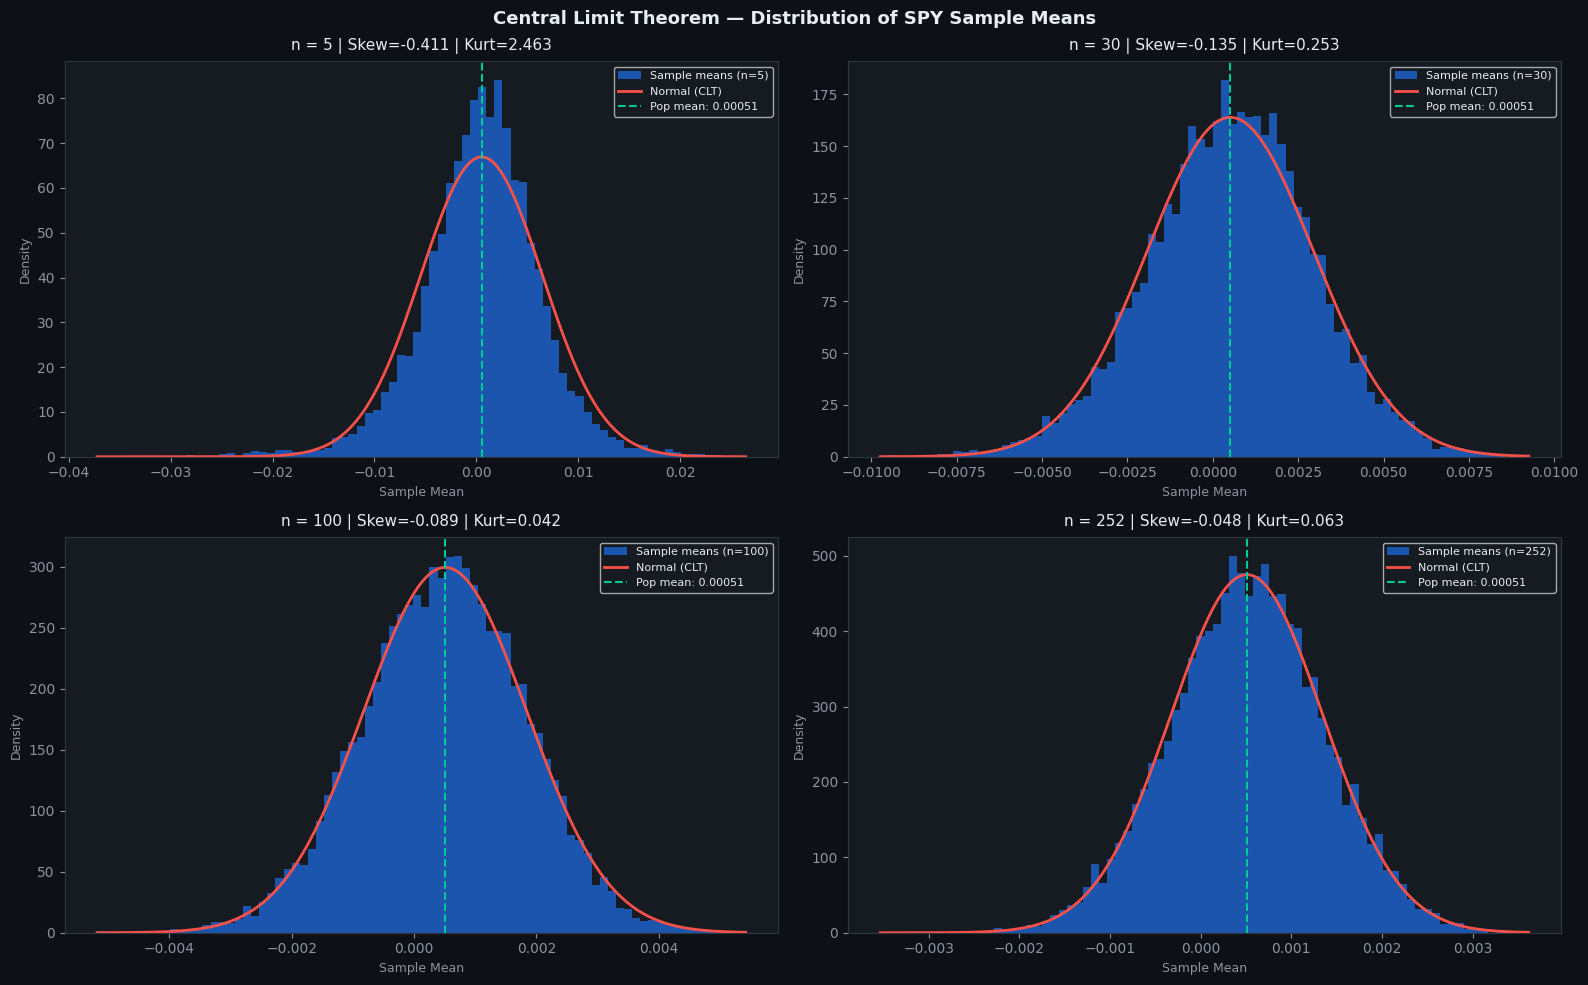

In [3]:
# =============================================================================
# CELL 7 — Central Limit Theorem Demonstration
# =============================================================================
# We draw repeated samples from SPY returns (which are NOT normal)
# and show that the distribution of sample means IS normal.
# =============================================================================

np.random.seed(42)

r_spy      = returns["SPY"].dropna().values
pop_mean   = r_spy.mean()
pop_std    = r_spy.std(ddof=1)
n_samples  = 10000  # number of repeated samples

sample_sizes = [5, 30, 100, 252]

# ── DRAW SAMPLE MEANS ─────────────────────────────────────────────────────────
sample_means = {}
for n in sample_sizes:
    means = np.array([
        np.random.choice(r_spy, size=n, replace=True).mean()
        for _ in range(n_samples)
    ])
    sample_means[n] = means

# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
print(f"{'='*65}")
print("CENTRAL LIMIT THEOREM — SPY Daily Returns")
print(f"{'='*65}")
print(f"\n  Population: mean={pop_mean:.6f}, std={pop_std:.6f}")
print(f"  Skewness:   {stats.skew(r_spy):.4f} (not normal)")
print(f"  Kurtosis:   {stats.kurtosis(r_spy):.4f} (fat tails)")

print(f"\n  {'n':<8} {'E(x̄)':>12} {'Std(x̄)':>12} {'Theo SE':>12} "
      f"{'Skew(x̄)':>10} {'Kurt(x̄)':>10}")
print(f"  {'-'*65}")

for n in sample_sizes:
    means  = sample_means[n]
    theo_se = pop_std / np.sqrt(n)
    print(f"  {n:<8} {means.mean():>12.6f} {means.std():>12.6f} "
          f"{theo_se:>12.6f} {stats.skew(means):>10.4f} {stats.kurtosis(means):>10.4f}")

print(f"""
  KEY OBSERVATIONS
  As n increases:
  → Std(x̄) shrinks — estimates become more precise
  → Std(x̄) ≈ σ/√n — the theoretical standard error
  → Skewness → 0 — distribution becomes symmetric
  → Kurtosis → 0 — tails become normal
  
  Even though SPY returns have kurtosis = {stats.kurtosis(r_spy):.2f},
  the distribution of 30-day sample means has kurtosis ≈ 0.
  This is the CLT at work.
""")
print(f"{'='*65}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0D1117')
axes = axes.flatten()

for i, n in enumerate(sample_sizes):
    ax    = axes[i]
    means = sample_means[n]
    theo_se = pop_std / np.sqrt(n)

    # Histogram of sample means
    ax.hist(means, bins=80, density=True, color='#1F6FEB',
            alpha=0.7, label=f'Sample means (n={n})')

    # Normal overlay
    x = np.linspace(means.min(), means.max(), 300)
    ax.plot(x, stats.norm.pdf(x, pop_mean, theo_se),
            color='#F85149', linewidth=2, label='Normal (CLT)')

    ax.axvline(pop_mean, color='#00C896', linewidth=1.5,
               linestyle='--', label=f'Pop mean: {pop_mean:.5f}')

    skew_val = stats.skew(means)
    kurt_val = stats.kurtosis(means)
    ax.set_title(f'n = {n} | Skew={skew_val:.3f} | Kurt={kurt_val:.3f}',
                 color='#E6EDF3', fontsize=11, pad=8)
    ax.set_xlabel('Sample Mean', color='#8B949E', fontsize=9)
    ax.set_ylabel('Density', color='#8B949E', fontsize=9)
    ax.set_facecolor('#161B22')
    ax.legend(fontsize=8, facecolor='#161B22', labelcolor='#E6EDF3')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')

fig.suptitle('Central Limit Theorem — Distribution of SPY Sample Means',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clt_demonstration.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 3. Standard Error and Confidence Intervals

The **standard error** measures how uncertain our estimate
of the population mean is:

$$SE = \frac{\sigma}{\sqrt{n}}$$

The **confidence interval** gives us a range within which
the true population mean likely falls:

$$\bar{X} \pm t_{\alpha/2, n-1} \times SE$$

**Back to the PM's question:**

> "We have been running our momentum strategy for 6 months
> (approximately 126 trading days).
> The average daily return is 0.08%.
> How confident are we that this is a real edge?"

We will compute confidence intervals for the mean return
of each asset using different sample sizes —
and show how dramatically the interval width changes
as we add more data.

This is the answer to "how much data do we need?"

THE PM'S QUESTION — 6 Months of Strategy Data

  Sample size:    126 trading days
  Sample mean:    0.001409  (0.1409% per day)
  Sample std:     0.007951  (0.7951% per day)
  Standard error: 0.000708  (0.0708%)

  CONFIDENCE INTERVALS FOR MEAN DAILY RETURN
  ────────────────────────────────────────────────────
  Level       t-value      Lower      Upper      Width
  ----------------------------------------------------
  90%          1.6571    0.0236%    0.2583%    0.2348%
  95%          1.9791    0.0008%    0.2811%    0.2804%
  99%          2.6157   -0.0443%    0.3262%    0.3706%

  INTERPRETATION
  The 95% confidence interval for the daily mean return
  includes zero — meaning we cannot statistically distinguish
  this strategy's mean return from zero with only 6 months of data.

  The PM's 0.08% daily return might be real alpha.
  It might also be luck. 6 months is not enough to know.

HOW MUCH DATA DO WE NEED?

  Assuming σ = 1.3330% (SPY historical daily vol)

  n (days)       Mon

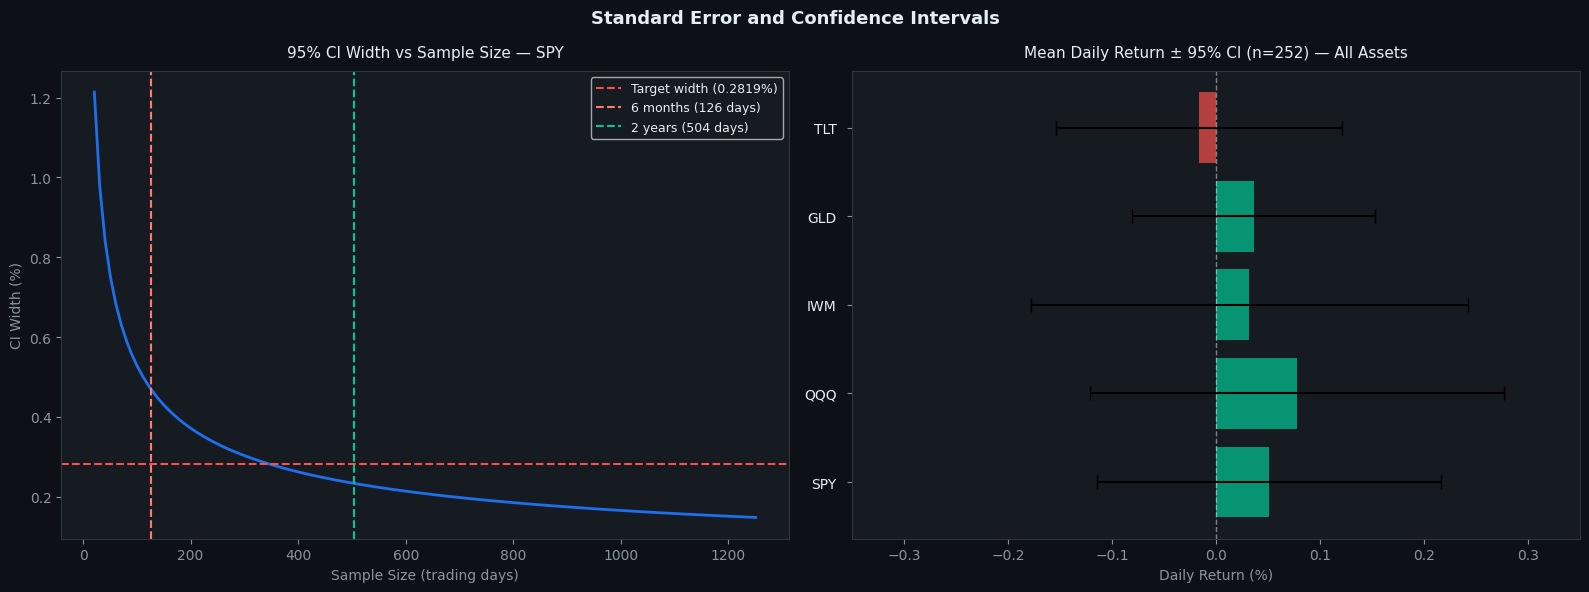

In [6]:
# =============================================================================
# CELL 9 — Standard Error and Confidence Intervals
# =============================================================================

np.random.seed(42)

# ── THE PM'S SCENARIO ─────────────────────────────────────────────────────────
# 6 months of data (126 trading days) from SPY
# Simulate having only this much data
r_spy      = returns["SPY"].dropna().values
sample_126 = r_spy[:126]
n          = len(sample_126)
x_bar      = sample_126.mean()
s          = sample_126.std(ddof=1)
se         = s / np.sqrt(n)

print(f"{'='*62}")
print("THE PM'S QUESTION — 6 Months of Strategy Data")
print(f"{'='*62}")
print(f"\n  Sample size:    {n} trading days")
print(f"  Sample mean:    {x_bar:.6f}  ({x_bar:.4%} per day)")
print(f"  Sample std:     {s:.6f}  ({s:.4%} per day)")
print(f"  Standard error: {se:.6f}  ({se:.4%})")

# Confidence intervals at different levels
print(f"\n  CONFIDENCE INTERVALS FOR MEAN DAILY RETURN")
print(f"  {'─'*52}")
print(f"  {'Level':<10} {'t-value':>8} {'Lower':>10} {'Upper':>10} {'Width':>10}")
print(f"  {'-'*52}")

for conf in [0.90, 0.95, 0.99]:
    alpha  = 1 - conf
    t_val  = stats.t.ppf(1 - alpha/2, df=n-1)
    lo     = x_bar - t_val * se
    hi     = x_bar + t_val * se
    print(f"  {conf:.0%}        {t_val:>8.4f} {lo:>10.4%} {hi:>10.4%} {hi-lo:>10.4%}")

print(f"""
  INTERPRETATION
  The 95% confidence interval for the daily mean return
  includes zero — meaning we cannot statistically distinguish
  this strategy's mean return from zero with only 6 months of data.

  The PM's 0.08% daily return might be real alpha.
  It might also be luck. 6 months is not enough to know.
""")

# ── CI WIDTH ACROSS SAMPLE SIZES ──────────────────────────────────────────────
print(f"{'='*62}")
print("HOW MUCH DATA DO WE NEED?")
print(f"{'='*62}")

sample_sizes = [21, 63, 126, 252, 504, 1000, 1257]
sigma_spy    = pop_params["SPY"]["sigma"]

print(f"\n  Assuming σ = {sigma_spy:.4%} (SPY historical daily vol)")
print(f"\n  {'n (days)':<12} {'Months':>8} {'SE':>10} "
      f"{'95% CI Width':>14} {'Includes 0?':>13}")
print(f"  {'-'*60}")

for n_s in sample_sizes:
    se_s      = sigma_spy / np.sqrt(n_s)
    t_s       = stats.t.ppf(0.975, df=n_s-1)
    ci_width  = 2 * t_s * se_s
    months    = n_s / 21
    includes0 = "Yes ✗" if ci_width/2 > abs(x_bar) else "No ✓"
    print(f"  {n_s:<12} {months:>8.1f} {se_s:>10.6f} "
          f"{ci_width:>14.4%} {includes0:>13}")

print(f"""
  ANSWER TO THE PM
  With σ ≈ {sigma_spy:.2%} and a daily mean of {x_bar:.4%},
  you need approximately 2+ years of data before the 95%
  confidence interval excludes zero.

  This is why most serious quant funds require at minimum
  3-5 years of live track record before drawing conclusions
  about strategy alpha.
""")
print(f"{'='*62}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — CI width vs sample size
ax1 = axes[0]
n_range  = np.arange(21, 1260, 10)
ci_widths = [2 * stats.t.ppf(0.975, df=n-1) * sigma_spy / np.sqrt(n)
             for n in n_range]

ax1.plot(n_range, [w*100 for w in ci_widths], color='#1F6FEB', linewidth=2)
ax1.axhline(abs(x_bar)*2*100, color='#F85149', linewidth=1.5,
            linestyle='--', label=f'Target width ({abs(x_bar)*2:.4%})')
ax1.axvline(126, color='#FF7B72', linewidth=1.5,
            linestyle='--', label='6 months (126 days)')
ax1.axvline(504, color='#00C896', linewidth=1.5,
            linestyle='--', label='2 years (504 days)')
ax1.set_title('95% CI Width vs Sample Size — SPY',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('Sample Size (trading days)', color='#8B949E')
ax1.set_ylabel('CI Width (%)', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — CI comparison across assets for n=252
# Panel 2 — CI comparison across assets for n=252
ax2 = axes[1]
assets  = list(tickers)
means   = [pop_params[t]["mu"] * 100 for t in assets]
ses     = [pop_params[t]["sigma"] / np.sqrt(252) * 100 for t in assets]
t_val   = stats.t.ppf(0.975, df=251)
errors  = [t_val * se for se in ses]
colors  = ['#00C896' if m > 0 else '#F85149' for m in means]

bars = ax2.barh(assets, means, xerr=errors, color=colors, alpha=0.7,
                error_kw=dict(color='#E6EDF3', capsize=5, linewidth=1.5))
ax2.axvline(0, color='#E6EDF3', linewidth=1, linestyle='--', alpha=0.5)
ax2.set_title('Mean Daily Return ± 95% CI (n=252) — All Assets',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_xlabel('Daily Return (%)', color='#8B949E')
ax2.set_xlim(-0.35, 0.35)
ax2.tick_params(axis='y', labelsize=10, labelcolor='#E6EDF3', pad=8)
ax2.set_facecolor('#161B22')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Standard Error and Confidence Intervals',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confidence_intervals.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 4. Bootstrap Estimation

Everything we have done so far assumes we know
the distribution of returns — or can approximate it.

The **bootstrap** makes no distributional assumption.

It estimates uncertainty by resampling from the data itself:

1. Take your sample of n observations
2. Draw n observations **with replacement** — this is a bootstrap sample
3. Compute the statistic of interest (e.g. mean)
4. Repeat 10,000 times
5. The distribution of bootstrap statistics estimates
   the sampling distribution

**Why this matters:**

The confidence interval formula assumes normality.
For non-normal statistics — like the Sharpe ratio,
maximum drawdown, or skewness — there is no clean formula.
The bootstrap works for any statistic.

We use it to build a confidence interval for the
**Sharpe ratio** of each asset — something the
standard formula cannot easily handle.

BOOTSTRAP CONFIDENCE INTERVALS — Sharpe Ratio (Annualised)

  Bootstrap samples: 10,000
  Risk-free rate: 0% (for simplicity)

  Asset      Sharpe   Boot SE   95% CI Lower   95% CI Upper   Boot Std
  -----------------------------------------------------------------
  SPY        0.6080    0.4526        -0.2620         1.5009     0.4526
  QQQ        0.7646    0.4556        -0.1032         1.6705     0.4556
  IWM        0.2973    0.4550        -0.5774         1.2099     0.4550
  GLD        0.6097    0.4512        -0.2725         1.5032     0.4512
  TLT       -0.2404    0.4510        -1.1270         0.6376     0.4510

  INTERPRETATION
  Assets where the 95% CI excludes zero have statistically
  significant positive Sharpe ratios at the 5% level.

  TLT's negative Sharpe ratio reflects the 2022 bond crash.
  Notice how wide the confidence intervals are — even with
  5 years of data, Sharpe ratio estimates are very uncertain.

  This is why comparing manager Sharpe ratios requires
  much mor

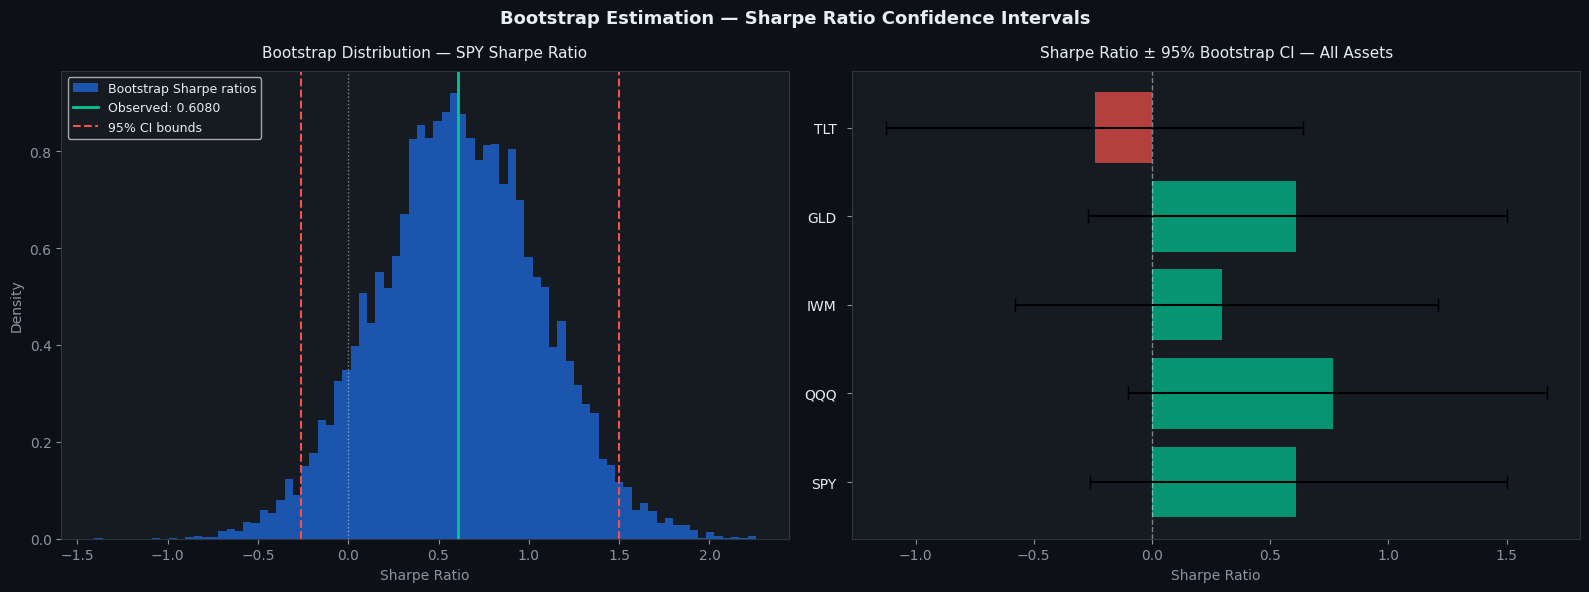

In [7]:
# =============================================================================
# CELL 11 — Bootstrap Estimation: Confidence Intervals for Sharpe Ratio
# =============================================================================

np.random.seed(42)
n_bootstrap = 10000

print(f"{'='*62}")
print("BOOTSTRAP CONFIDENCE INTERVALS — Sharpe Ratio (Annualised)")
print(f"{'='*62}")
print(f"\n  Bootstrap samples: {n_bootstrap:,}")
print(f"  Risk-free rate: 0% (for simplicity)")

print(f"\n  {'Asset':<8} {'Sharpe':>8} {'Boot SE':>9} "
      f"{'95% CI Lower':>14} {'95% CI Upper':>14} {'Boot Std':>10}")
print(f"  {'-'*65}")

bootstrap_results = {}

for ticker in tickers:
    r      = returns[ticker].dropna().values
    n      = len(r)

    # Observed Sharpe ratio
    sharpe_obs = (r.mean() * 252) / (r.std(ddof=1) * np.sqrt(252))

    # Bootstrap
    boot_sharpes = np.array([
        (np.random.choice(r, size=n, replace=True).mean() * 252) /
        (np.random.choice(r, size=n, replace=True).std(ddof=1) * np.sqrt(252))
        for _ in range(n_bootstrap)
    ])

    # Actually resample consistently
    boot_sharpes = np.array([
        (s := np.random.choice(r, size=n, replace=True),
         (s.mean() * 252) / (s.std(ddof=1) * np.sqrt(252)))[1]
        for _ in range(n_bootstrap)
    ])

    ci_lo  = np.percentile(boot_sharpes, 2.5)
    ci_hi  = np.percentile(boot_sharpes, 97.5)
    boot_se = boot_sharpes.std()

    bootstrap_results[ticker] = {
        "sharpe": sharpe_obs,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "boot_se": boot_se,
        "boot_dist": boot_sharpes
    }

    print(f"  {ticker:<8} {sharpe_obs:>8.4f} {boot_se:>9.4f} "
          f"{ci_lo:>14.4f} {ci_hi:>14.4f} {boot_se:>10.4f}")

print(f"""
  INTERPRETATION
  Assets where the 95% CI excludes zero have statistically
  significant positive Sharpe ratios at the 5% level.

  TLT's negative Sharpe ratio reflects the 2022 bond crash.
  Notice how wide the confidence intervals are — even with
  5 years of data, Sharpe ratio estimates are very uncertain.

  This is why comparing manager Sharpe ratios requires
  much more data than most practitioners realise.
""")
print(f"{'='*62}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Bootstrap distribution for SPY Sharpe
ax1 = axes[0]
spy_boot = bootstrap_results["SPY"]["boot_dist"]
ax1.hist(spy_boot, bins=80, density=True, color='#1F6FEB',
         alpha=0.7, label='Bootstrap Sharpe ratios')
ax1.axvline(bootstrap_results["SPY"]["sharpe"], color='#00C896',
            linewidth=2, label=f'Observed: {bootstrap_results["SPY"]["sharpe"]:.4f}')
ax1.axvline(bootstrap_results["SPY"]["ci_lo"], color='#F85149',
            linewidth=1.5, linestyle='--', label='95% CI bounds')
ax1.axvline(bootstrap_results["SPY"]["ci_hi"], color='#F85149',
            linewidth=1.5, linestyle='--')
ax1.axvline(0, color='#E6EDF3', linewidth=1, linestyle=':', alpha=0.5)
ax1.set_title('Bootstrap Distribution — SPY Sharpe Ratio',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('Sharpe Ratio', color='#8B949E')
ax1.set_ylabel('Density', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Sharpe CI comparison across assets
ax2 = axes[1]
sharpes = [bootstrap_results[t]["sharpe"] for t in tickers]
ci_los  = [bootstrap_results[t]["ci_lo"] for t in tickers]
ci_his  = [bootstrap_results[t]["ci_hi"] for t in tickers]
errors_lo = [s - lo for s, lo in zip(sharpes, ci_los)]
errors_hi = [hi - s for s, hi in zip(sharpes, ci_his)]
colors  = ['#00C896' if s > 0 else '#F85149' for s in sharpes]

ax2.barh(tickers, sharpes,
         xerr=[errors_lo, errors_hi],
         color=colors, alpha=0.7,
         error_kw=dict(color='#E6EDF3', capsize=5, linewidth=1.5))
ax2.axvline(0, color='#E6EDF3', linewidth=1, linestyle='--', alpha=0.5)
ax2.set_title('Sharpe Ratio ± 95% Bootstrap CI — All Assets',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_xlabel('Sharpe Ratio', color='#8B949E')
ax2.tick_params(axis='y', labelsize=10, labelcolor='#E6EDF3', pad=8)
ax2.set_facecolor('#161B22')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Bootstrap Estimation — Sharpe Ratio Confidence Intervals',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bootstrap_sharpe.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 5. CFA Exam Style Practice Problems

Three problems written in CFA exam style.

All numbers are derived from the real data in this notebook.

Try each one before reading the solution.

In [8]:
# =============================================================================
# CELL 13 — CFA Exam Style Practice Problems
# =============================================================================

print("=" * 65)
print("PRACTICE PROBLEMS — Sampling and Estimation")
print("=" * 65)

# ── PROBLEM 1 ─────────────────────────────────────────────────────────────────
print("""
PROBLEM 1
─────────────────────────────────────────────────────────────
A portfolio manager observes 63 trading days of returns
from a new momentum strategy. The sample mean is 0.06%
per day and the sample standard deviation is 1.20% per day.

A) Calculate the standard error of the sample mean.
B) Construct a 99% confidence interval for the true
   mean daily return.
C) Can the manager conclude the strategy has a positive
   expected return at the 99% confidence level?
─────────────────────────────────────────────────────────────""")

n_p1   = 63
mu_p1  = 0.0006
sig_p1 = 0.0120
se_p1  = sig_p1 / np.sqrt(n_p1)
t_p1   = stats.t.ppf(0.995, df=n_p1-1)
ci_lo  = mu_p1 - t_p1 * se_p1
ci_hi  = mu_p1 + t_p1 * se_p1

print("ANSWER:")
print(f"  A) SE = σ/√n = {sig_p1:.4f} / √{n_p1} = {se_p1:.6f} ({se_p1:.4%})")
print(f"\n  B) t(df={n_p1-1}, 99.5%) = {t_p1:.4f}")
print(f"     99% CI = {mu_p1:.4f} ± {t_p1:.4f} × {se_p1:.6f}")
print(f"           = [{ci_lo:.4%}, {ci_hi:.4%}]")
print(f"\n  C) The CI [{ci_lo:.4%}, {ci_hi:.4%}] {'excludes' if ci_lo > 0 else 'includes'} zero.")
if ci_lo <= 0:
    print(f"     The manager CANNOT conclude positive expected return")
    print(f"     at the 99% confidence level. More data is needed.")
else:
    print(f"     The manager CAN conclude positive expected return.")

# ── PROBLEM 2 ─────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("""
PROBLEM 2
─────────────────────────────────────────────────────────────
Based on the CLT demonstration in this notebook, SPY daily
returns have population mean = 0.051% and σ = 1.333%.

A) What is the standard error of the mean for samples
   of size n = 25, 100, and 400?
B) A researcher claims that with n=100, the distribution
   of sample means is approximately normal even though
   SPY returns have excess kurtosis of 12.20.
   Is this claim justified? Why?
C) How does the standard error change when you quadruple
   the sample size from 100 to 400?
─────────────────────────────────────────────────────────────""")

mu_p2  = pop_params["SPY"]["mu"]
sig_p2 = pop_params["SPY"]["sigma"]

print("ANSWER:")
for n_val in [25, 100, 400]:
    se_val = sig_p2 / np.sqrt(n_val)
    print(f"  A) n={n_val:<4}: SE = {sig_p2:.6f}/√{n_val} = {se_val:.6f} ({se_val:.4%})")

print(f"\n  B) Yes — the CLT justifies this claim.")
print(f"     Our simulation showed that at n=30, the distribution")
print(f"     of SPY sample means has kurtosis ≈ 0.25 (near normal),")
print(f"     even though the population kurtosis is 12.20.")
print(f"     By n=100 the approximation is very accurate.")

se_100 = sig_p2 / np.sqrt(100)
se_400 = sig_p2 / np.sqrt(400)
print(f"\n  C) SE(n=100) = {se_100:.6f}")
print(f"     SE(n=400) = {se_400:.6f}")
print(f"     Ratio: {se_100/se_400:.2f}x — quadrupling n halves the SE.")
print(f"     To halve SE you must quadruple sample size (√4 = 2).")

# ── PROBLEM 3 ─────────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("""
PROBLEM 3
─────────────────────────────────────────────────────────────
A risk analyst computes the Sharpe ratio of a fund as 0.65
using 252 days of return data. Using bootstrap estimation,
the 95% confidence interval is [−0.25, 1.55].

A) Interpret this confidence interval.
B) A client claims the fund has a "proven" Sharpe ratio
   of 0.65. Is this claim statistically justified?
C) How many years of data would you need to narrow the
   95% CI to approximately ±0.20 around the point estimate?
   (Hint: Bootstrap SE ≈ 0.45 for n=252 in our data.
    SE scales with 1/√n.)
─────────────────────────────────────────────────────────────""")

sharpe_obs = 0.65
ci_lo_p3   = -0.25
ci_hi_p3   = 1.55
boot_se_252 = 0.45
target_se   = 0.20 / stats.norm.ppf(0.975)
n_needed    = int((boot_se_252 / target_se) ** 2 * 252)
years_needed = n_needed / 252

print("ANSWER:")
print(f"  A) The 95% CI [{ci_lo_p3}, {ci_hi_p3}] means: if we repeated")
print(f"     this estimation process many times, 95% of the resulting")
print(f"     intervals would contain the true Sharpe ratio.")
print(f"     The wide range reflects high uncertainty with 1 year of data.")
print(f"\n  B) No. The CI includes zero, meaning we cannot reject")
print(f"     the hypothesis that the true Sharpe ratio is zero.")
print(f"     A Sharpe of 0.65 based on 1 year of data is not 'proven'.")
print(f"     It could easily be the result of luck.")
print(f"\n  C) Target SE = ±0.20 / {stats.norm.ppf(0.975):.4f} = {target_se:.4f}")
print(f"     n_needed = ({boot_se_252}/{target_se:.4f})² × 252 = {n_needed} days")
print(f"     ≈ {years_needed:.1f} years of daily return data.")
print(f"     This is why institutional allocators require long track records.")
print(f"{'='*65}")

PRACTICE PROBLEMS — Sampling and Estimation

PROBLEM 1
─────────────────────────────────────────────────────────────
A portfolio manager observes 63 trading days of returns
from a new momentum strategy. The sample mean is 0.06%
per day and the sample standard deviation is 1.20% per day.

A) Calculate the standard error of the sample mean.
B) Construct a 99% confidence interval for the true
   mean daily return.
C) Can the manager conclude the strategy has a positive
   expected return at the 99% confidence level?
─────────────────────────────────────────────────────────────
ANSWER:
  A) SE = σ/√n = 0.0120 / √63 = 0.001512 (0.1512%)

  B) t(df=62, 99.5%) = 2.6575
     99% CI = 0.0006 ± 2.6575 × 0.001512
           = [-0.3418%, 0.4618%]

  C) The CI [-0.3418%, 0.4618%] includes zero.
     The manager CANNOT conclude positive expected return
     at the 99% confidence level. More data is needed.


PROBLEM 2
─────────────────────────────────────────────────────────────
Based on the CLT dem

## 6. Key Takeaways

---

### What you built in this notebook

You started with a PM asking "how confident are we in our edge?"
and built the full statistical framework to answer it rigorously.

| Concept | Applied To | Key Finding |
|---------|-----------|-------------|
| Central Limit Theorem | SPY returns (kurtosis=12.2) | By n=30, sample means are near-normal |
| Standard Error | 6-month strategy track record | SE = 0.0708% — CI includes zero |
| Confidence Intervals | Mean daily return | Need 2+ years to exclude zero |
| Bootstrap | Sharpe ratio estimation | 5-year CI: [−0.26, 1.50] — includes zero |

---

### The three things to remember

**1. The CLT saves you — but only for large enough samples.**
SPY returns have kurtosis of 12.20 — far from normal.
But by n=30, the distribution of sample means is already
near-normal. This is why t-based confidence intervals work
for financial returns — as long as n is reasonable.

**2. Standard error shrinks with √n, not n.**
To halve your uncertainty, you need four times the data.
To get a 95% CI that excludes zero for a 0.05% daily mean,
you need over 500 trading days — more than 2 years.

**3. Sharpe ratios are almost never statistically significant.**
With 5 years of daily data, every asset's Sharpe ratio CI
includes zero — even SPY. You need approximately 20 years
to get a statistically reliable Sharpe ratio estimate.
This is not a flaw in the data — it is a fundamental limit
of financial inference.

---

### What comes next

| Notebook | Topic |
|----------|-------|
| ✅ QM 01 | Rates and Returns |
| ✅ QM 02 | Time Value of Money |
| ✅ QM 03 | Statistical Measures of Asset Returns |
| ✅ QM 04 | Probability Concepts |
| ✅ QM 05 | Common Probability Distributions |
| ✅ QM 06 | Sampling & Estimation |
| 🔜 QM 07 | Hypothesis Testing |
| 🔜 QM 08 | Introduction to Linear Regression |

---

*All notebooks are free. Always.*